In [31]:
# imports
import glob
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from dotenv import load_dotenv
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, matthews_corrcoef

# Loading

In [36]:
load_dotenv()
path = kagglehub.dataset_download("chethuhn/network-intrusion-dataset")

# read all CSV files in the dataset directory, create df
csv_files = glob.glob(os.path.join(path, "*.csv"))
df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)
print(f"Shape: {df.shape}")

Shape: (2830743, 79)


# Cleaning

In [37]:
# clean up column names
df.columns = df.columns.str.strip()

# clean up label names
df['Label'] = df['Label'].str.strip().str.replace('�', '-')

In [38]:
# replace na and inf with 0
df = df.fillna(0)
df = df.replace([np.inf, -np.inf], 0)

In [39]:
# remove duplicates rows
df = df.drop_duplicates(keep='first')

# remove duplicate columns
duplicate_columns = set()
for i in range(df.shape[1]):
    col_i = df.iloc[:, i]
    for j in range(i + 1, df.shape[1]):
        col_j = df.iloc[:, j]
        if col_i.equals(col_j):
            duplicate_columns.add(df.columns[j])

print(f"Duplicate columns: {duplicate_columns}")
df = df.drop(columns=list(duplicate_columns))

print(f"Shape: {df.shape}")

Duplicate columns: {'Fwd Avg Bulk Rate', 'Fwd Avg Bytes/Bulk', 'Subflow Bwd Packets', 'CWE Flag Count', 'Fwd Header Length.1', 'Bwd Avg Packets/Bulk', 'Bwd URG Flags', 'Bwd Avg Bytes/Bulk', 'Subflow Fwd Packets', 'Bwd Avg Bulk Rate', 'Fwd Avg Packets/Bulk', 'SYN Flag Count'}
Shape: (2522362, 67)


# Visualization

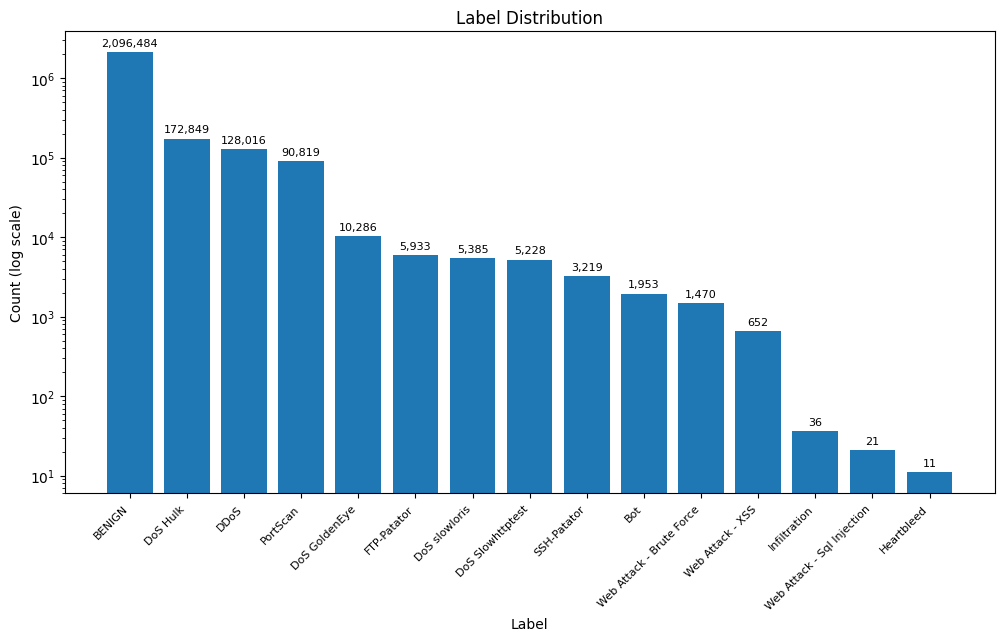

In [42]:
# plot label distribution
label_counts = df['Label'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(label_counts.index, label_counts.values)
ax.set_yscale('log') # log scale since the benign class is so large
ax.set_xlabel('Label')
ax.set_ylabel('Count (log scale)')
ax.set_title('Label Distribution')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.bar_label(bars, labels=[f'{c:,}' for c in label_counts.values], fontsize=8, padding=3)
plt.show()

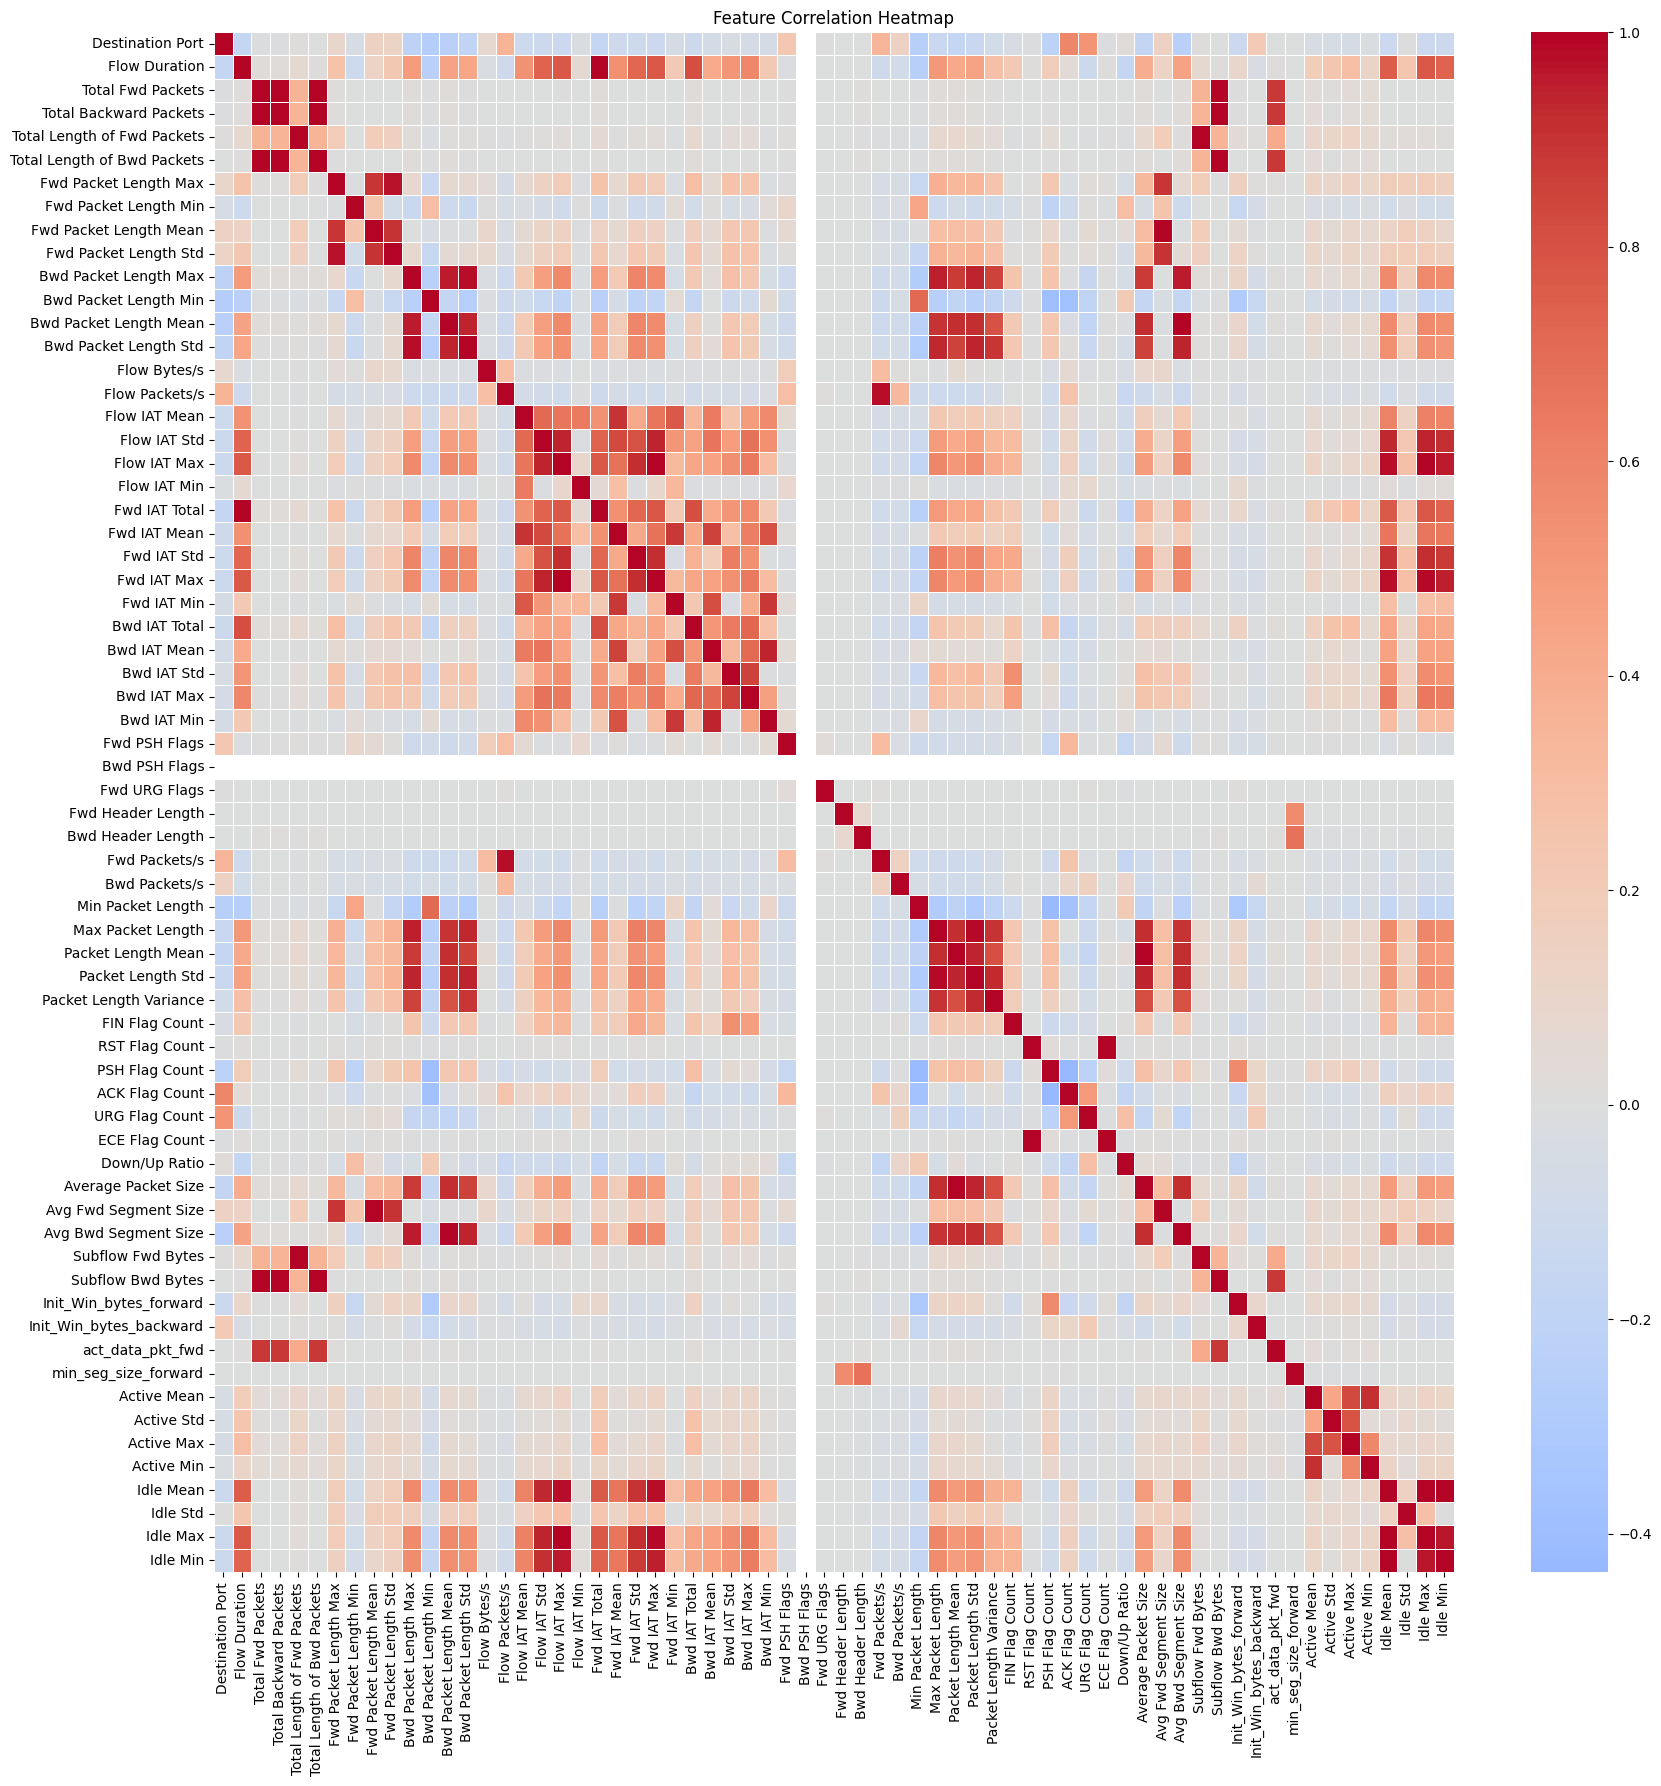

In [47]:
# Calculate correlation matrix
corr_matrix = df.select_dtypes(include='number').corr()

# Plot correlation heatmap
plt.figure(figsize=(20, 20))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, linewidth = 0.5)
plt.title('Feature Correlation Heatmap')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

In [53]:
# extract highly correlated features
threshold = 0.95
high_corr = np.where(np.abs(corr_matrix) > threshold)
high_corr = [(corr_matrix.index[x], corr_matrix.columns[y], corr_matrix.iloc[x, y])
             for x, y in zip(*high_corr) if x != y and x < y]

# pretty print
for item in high_corr:
    print(f'{item[0]} highly correlated with {item[1]}: {item[2].round(4)}')

Flow Duration highly correlated with Fwd IAT Total: 0.9985
Total Fwd Packets highly correlated with Total Backward Packets: 0.9991
Total Fwd Packets highly correlated with Total Length of Bwd Packets: 0.997
Total Fwd Packets highly correlated with Subflow Bwd Bytes: 0.997
Total Backward Packets highly correlated with Total Length of Bwd Packets: 0.9944
Total Backward Packets highly correlated with Subflow Bwd Bytes: 0.9944
Total Length of Fwd Packets highly correlated with Subflow Fwd Bytes: 1.0
Total Length of Bwd Packets highly correlated with Subflow Bwd Bytes: 1.0
Fwd Packet Length Max highly correlated with Fwd Packet Length Std: 0.9685
Fwd Packet Length Mean highly correlated with Avg Fwd Segment Size: 1.0
Bwd Packet Length Max highly correlated with Bwd Packet Length Mean: 0.9582
Bwd Packet Length Max highly correlated with Bwd Packet Length Std: 0.9825
Bwd Packet Length Max highly correlated with Avg Bwd Segment Size: 0.9582
Bwd Packet Length Mean highly correlated with Avg Bwd

# Training

In [ ]:
# create feature and target datasets
y = df['Label']
X = df.drop(columns=['Label'])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier( n_estimators=10, max_depth=None, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

print(classification_report(y_test, clf.predict(X_test)))

In [45]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)